In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm

Clean up the data by dropping the empty columns and standardizing dates

In [7]:
df = pd.read_csv("./AMZN_NQ_24-25.csv")
df = df.drop(df.columns[[-1, -2, -3]], axis=1)
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by="Date", ascending=True, inplace=True)
print(df)


          Date Close/Last    Volume     Open     High      Low
249 2024-02-16    $169.51  48107740  $168.74  $170.42  $167.17
248 2024-02-20    $167.08  41980330  $167.83  $168.71  $165.74
247 2024-02-21    $168.59  44575620  $168.94  $170.23  $167.14
246 2024-02-22    $174.58  55392350  $173.10  $174.80  $171.77
245 2024-02-23    $174.99  59715240  $174.28  $175.75  $173.70
..         ...        ...       ...      ...      ...      ...
4   2025-02-10    $233.14  35419930  $230.55  $233.92  $229.20
3   2025-02-11    $232.76  23713730  $231.92  $233.44  $230.13
2   2025-02-12    $228.93  32285250  $230.46  $231.18  $228.16
1   2025-02-13    $230.37  31346510  $228.85  $230.42  $227.52
0   2025-02-14    $228.68  27031080  $229.20  $229.89  $227.23

[250 rows x 6 columns]


In [8]:
df["Close/Last"] = df["Close/Last"].str.replace("$", "", regex=False)
df["Close/Last"] = df["Close/Last"].str.replace(",", "", regex=False)
df["Close/Last"] = df["Close/Last"].astype(float)
df["Daily Return"] = df["Close/Last"].dropna().pct_change()
print(df)

          Date  Close/Last    Volume     Open     High      Low  Daily Return
249 2024-02-16      169.51  48107740  $168.74  $170.42  $167.17           NaN
248 2024-02-20      167.08  41980330  $167.83  $168.71  $165.74     -0.014335
247 2024-02-21      168.59  44575620  $168.94  $170.23  $167.14      0.009038
246 2024-02-22      174.58  55392350  $173.10  $174.80  $171.77      0.035530
245 2024-02-23      174.99  59715240  $174.28  $175.75  $173.70      0.002348
..         ...         ...       ...      ...      ...      ...           ...
4   2025-02-10      233.14  35419930  $230.55  $233.92  $229.20      0.017412
3   2025-02-11      232.76  23713730  $231.92  $233.44  $230.13     -0.001630
2   2025-02-12      228.93  32285250  $230.46  $231.18  $228.16     -0.016455
1   2025-02-13      230.37  31346510  $228.85  $230.42  $227.52      0.006290
0   2025-02-14      228.68  27031080  $229.20  $229.89  $227.23     -0.007336

[250 rows x 7 columns]


In [9]:
print(df["Daily Return"].quantile(0.05))
print(df["Daily Return"].sort_values().iloc[13])

x_bar = df["Daily Return"].dropna().mean()
s2 = df["Daily Return"].dropna().std(ddof=1)

return_dist = norm(loc=x_bar, scale=s2)
zero_centered_return_dist = norm(loc=0, scale=s2)
print(return_dist.ppf(0.05))
print(zero_centered_return_dist.ppf(0.05))

-0.025099712569223387
-0.024332810047095865
-0.026993163343510165
-0.028344967746649796


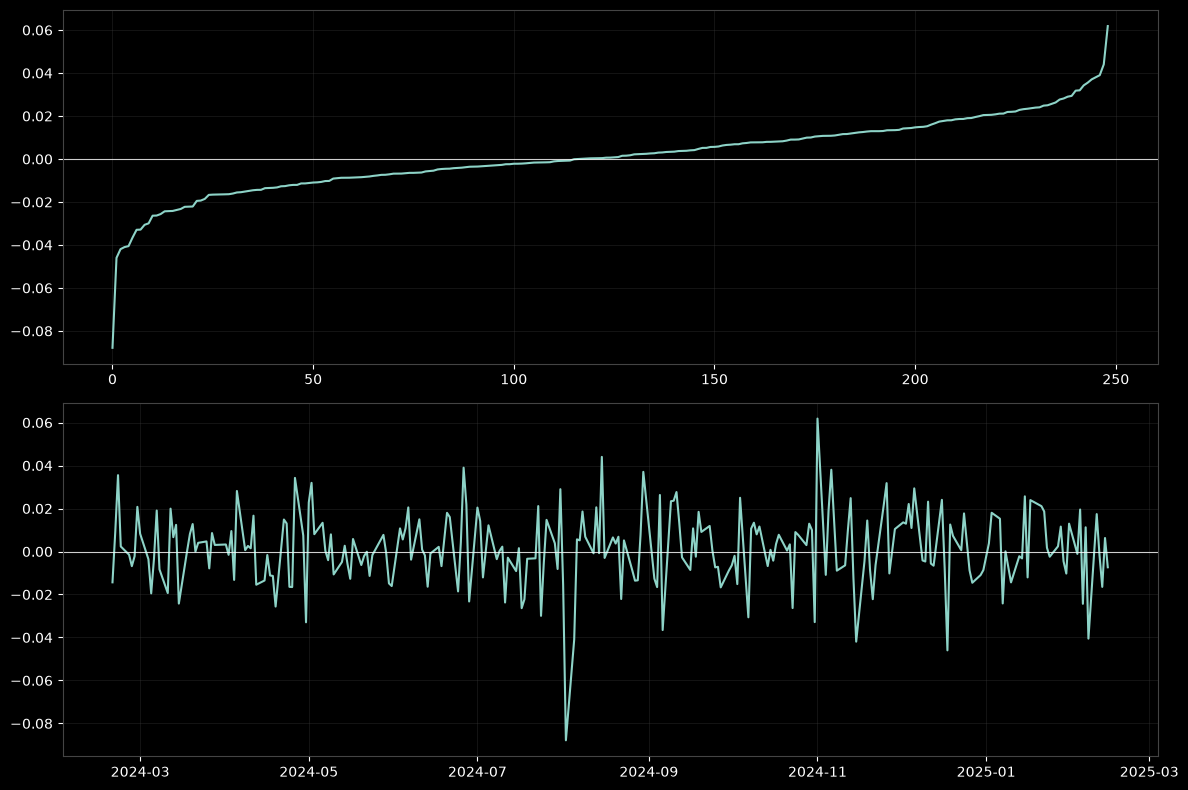

In [ ]:
plt.style.use("dark_background")
plt.rcParams.update({
    "axes.facecolor": "#000000",
    "figure.facecolor": "#000000",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "legend.facecolor": "#111111",
    "legend.edgecolor": "#222222",
    "font.size": 10
})

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=False,
)
axes[0].plot(range(len(df)), df["Daily Return"].sort_values())
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color="white", linewidth=0.8, alpha=0.8)

axes[1].plot(df["Date"], df["Daily Return"])
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color="white", linewidth=0.8, alpha=0.8)

fig.tight_layout()
plt.show()